<a href="https://colab.research.google.com/github/gauriap0/goec-surveillance-detection/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 65.2 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow

# Cars
rf = Roboflow(api_key="tbqeGtE3xGaabPu2Dz0G")
project = rf.workspace("drink-tracker").project("car-detection-pn2gk")
version = project.version(1)
dataset1 = version.download("yolov8")

# Fire and Smoke
rf = Roboflow(api_key="tbqeGtE3xGaabPu2Dz0G")
project = rf.workspace("fire-project").project("fire-and-smoke-lkzok")
version = project.version(7)
dataset2 = version.download("yolov8")

# GOEC (guns)
rf = Roboflow(api_key="9kYAcrA7GzElMnTccH01")
project = rf.workspace("annotation-0pigh").project("goec")
version = project.version(4)
dataset3 = version.download("yolov8")

print("All datasets downloaded!")
print(f"Cars: {dataset1.location}")
print(f"Fire: {dataset2.location}")
print(f"GOEC: {dataset3.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to car-detection-1 in yolov8:: 100%|██████████| 20012/20012 [00:03<00:00, 5882.16it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-and-Smoke-7 in yolov8:: 100%|██████████| 23874/23874 [00:03<00:00, 7745.52it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to GOEC-4 in yolov8:: 100%|██████████| 5945/5945 [00:00<00:00, 6333.96it/s]


All datasets downloaded!
Cars: /content/car-detection-1
Fire: /content/Fire-and-Smoke-7
GOEC: /content/GOEC-4


In [ ]:
import os
import shutil
import random

random.seed(42)

# ── Split GOEC-4 into train/valid/test ────────────────────────────────────────
goec_images = os.listdir(f"{dataset3.location}/train/images")
random.shuffle(goec_images)

total = len(goec_images)
train_end = int(0.7 * total)
valid_end = int(0.9 * total)

goec_splits = {
    "train": goec_images[:train_end],
    "valid": goec_images[train_end:valid_end],
    "test":  goec_images[valid_end:]
}

limits = {
    "train": min(len(goec_splits["train"]), 7500, 8468),
    "valid": min(len(goec_splits["valid"]), 1500, 2314),
    "test":  min(len(goec_splits["test"]),  1000, 1149)
}

# ── Create output folders ─────────────────────────────────────────────────────
for split in ["train", "valid", "test"]:
    os.makedirs(f"combined/{split}/images", exist_ok=True)
    os.makedirs(f"combined/{split}/labels", exist_ok=True)

def copy_files(dataset, split, filenames, limit, prefix):
    filenames = random.sample(filenames, min(limit, len(filenames)))
    for fname in filenames:
        name = os.path.splitext(fname)[0]
        src_img = f"{dataset}/{split}/images/{fname}"
        src_lbl = f"{dataset}/{split}/labels/{name}.txt"
        dst_img = f"combined/{split}/images/{prefix}_{fname}"
        dst_lbl = f"combined/{split}/labels/{prefix}_{name}.txt"
        if os.path.exists(src_img):
            shutil.copy(src_img, dst_img)
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)

# Copy Cars
for split in ["train", "valid", "test"]:
    imgs = os.listdir(f"{dataset1.location}/{split}/images")
    copy_files(dataset1.location, split, imgs, limits[split], "car")

# Copy Fire and Smoke
for split in ["train", "valid", "test"]:
    imgs = os.listdir(f"{dataset2.location}/{split}/images")
    copy_files(dataset2.location, split, imgs, limits[split], "fire")

# Copy GOEC
for split in ["train", "valid", "test"]:
    imgs = goec_splits[split]
    for fname in random.sample(imgs, min(limits[split], len(imgs))):
        name = os.path.splitext(fname)[0]
        src_img = f"{dataset3.location}/train/images/{fname}"
        src_lbl = f"{dataset3.location}/train/labels/{name}.txt"
        dst_img = f"combined/{split}/images/goec_{fname}"
        dst_lbl = f"combined/{split}/labels/goec_{name}.txt"
        if os.path.exists(src_img):
            shutil.copy(src_img, dst_img)
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)

print("Done! Combined dataset created.")
for split in ["train", "valid", "test"]:
    count = len(os.listdir(f"combined/{split}/images"))
    print(f"{split}: {count} images")

Done! Combined dataset created.
train: 6237 images
valid: 1782 images
test: 891 images


In [ ]:
yaml_content = """names:
- car
- fire
- gun
- smoke
nc: 4
train: /content/combined/train/images
val: /content/combined/valid/images
test: /content/combined/test/images
"""

with open("combined/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml fixed!")

data.yaml fixed!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="combined/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device="cuda",
    project="runs/train",
    name="combined_v1",
    save=True,
)

print("Training complete!")
print("Best weights: runs/train/combined_v1/weights/best.pt")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=combined/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=combined_v12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

In [ ]:
from google.colab import files
files.download('/content/runs/detect/runs/train/combined_v12/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/runs/train/combined_v12/weights/best.pt')

results = model.predict(
    source='/content/combined/test/images',
    conf=0.25,
    save=True,
    project='runs/test',
    name='results'
)

print("Done! Results saved.")


image 1/891 /content/combined/test/images/car_000297578acb067b_jpg.rf.4748165575afa020176198742f43f305.jpg: 640x640 1 car, 17.2ms
image 2/891 /content/combined/test/images/car_000472189adb5cbd_jpg.rf.1159b5f6af54206fc6628fd5a4c94f4c.jpg: 640x640 3 cars, 54.5ms
image 3/891 /content/combined/test/images/car_00058138dc1ecd17_jpg.rf.dfeb1ef3fc9206d4b11e27dd953cd7ac.jpg: 640x640 2 cars, 57.7ms
image 4/891 /content/combined/test/images/car_000e7c5f11d82f1a_jpg.rf.309e92efda969f82dea0d624daee93b3.jpg: 640x640 (no detections), 62.0ms
image 5/891 /content/combined/test/images/car_00118c8deaacd309_jpg.rf.16483ee1ceb4909dc66463758f0fa338.jpg: 640x640 2 cars, 35.3ms
image 6/891 /content/combined/test/images/car_001296b93b636dfb_jpg.rf.2fa8eb565618ed2723d3904c7c4134d6.jpg: 640x640 1 car, 47.0ms
image 7/891 /content/combined/test/images/car_001493fd26374606_jpg.rf.e1b638cfc61da4ee8a03a8bfa6da5f4a.jpg: 640x640 2 cars, 46.6ms
image 8/891 /content/combined/test/images/car_00155bc9538a26ed_jpg.rf.e9b34

fire_middle_-798-_jpg.rf.471fc425a2928921d83b908c6ac3a6a8.jpg


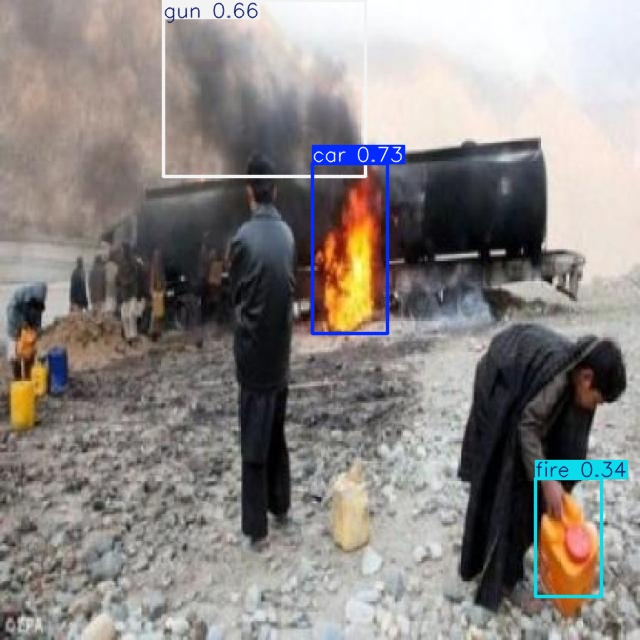

goec_car2_mp4-0079_jpg.rf.542262af86abc29d1f03075d0641ab01.jpg


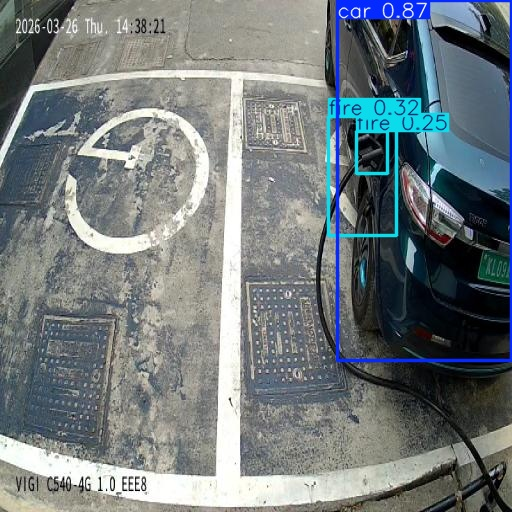

car_0cdb464a57be70b6_jpg.rf.8f2a539a051a4eeddc885182b027e3b3.jpg


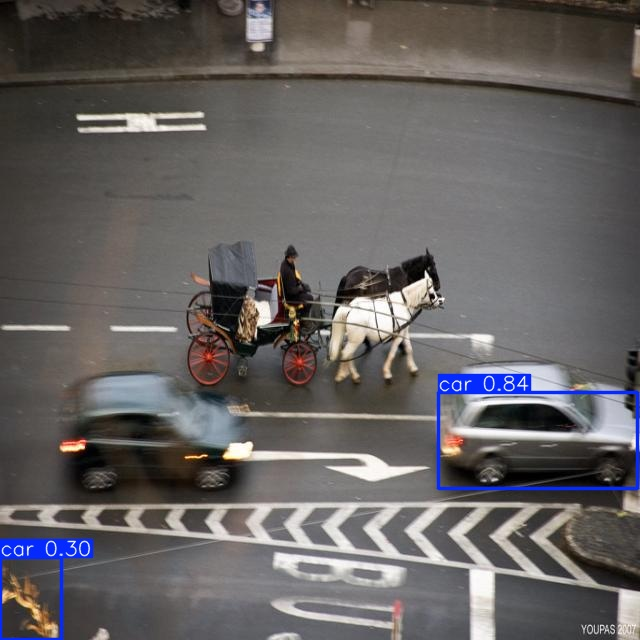

goec_output6-00_19_24_992-00_20_07_882-seg8_mp4-0001_jpg.rf.cf7d0a47781ca0842a1d44ac3c577bf0.jpg


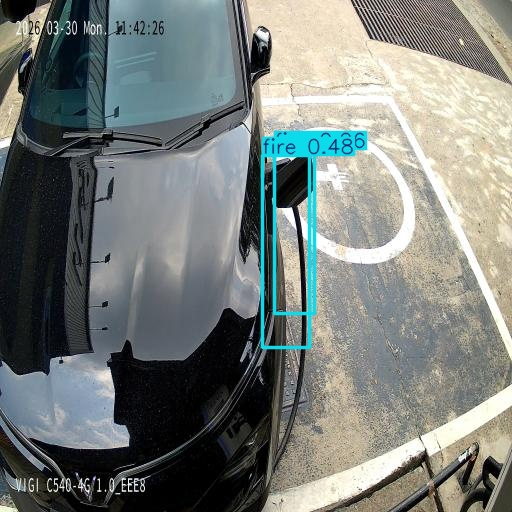

fire_other_-978-_jpg.rf.255e40f4e69851ded3308b0a8679d3f2.jpg


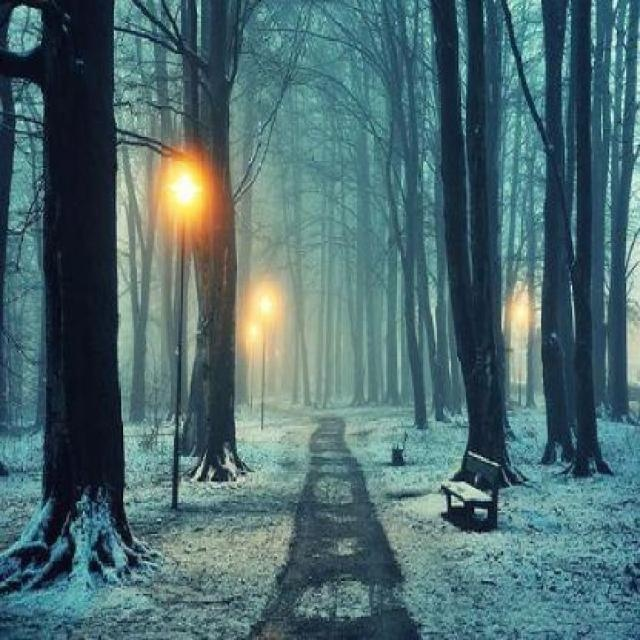

car_15af592f8372321d_jpg.rf.1b74dbad66c6438b7c390a07cd35f3cc.jpg


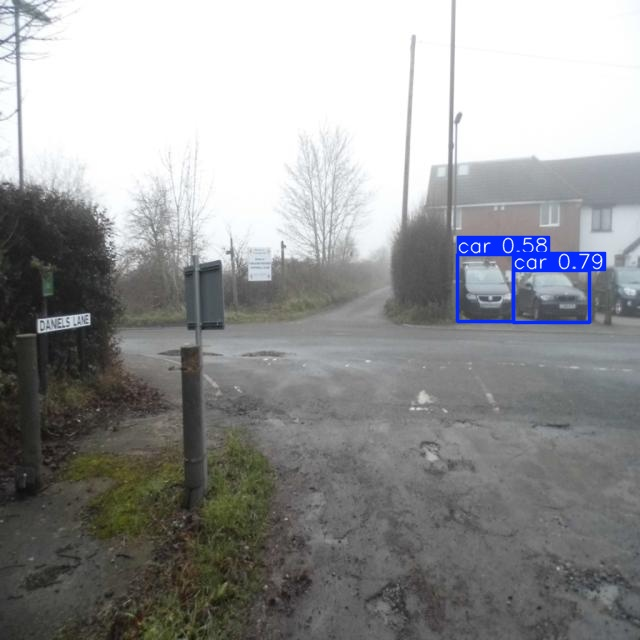

car_01b8f082ffa7e14d_jpg.rf.ea60182e2b904289a70e780164146b6e.jpg


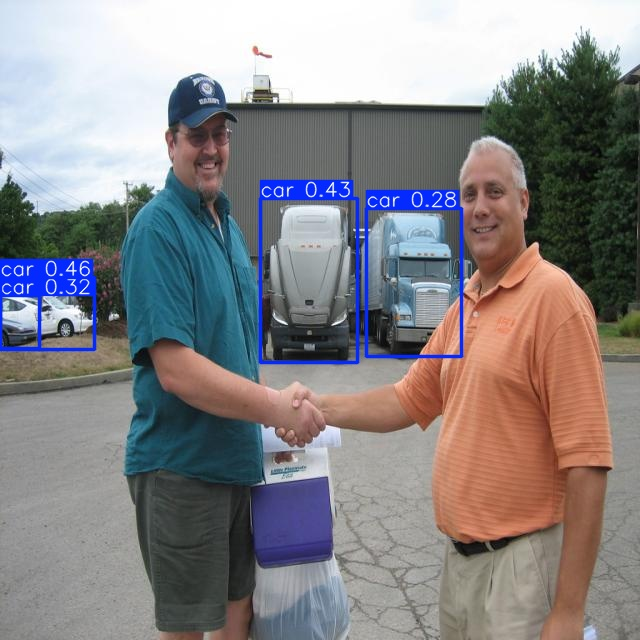

fire_200449_jpg.rf.7b25d3bc98eb2b783810dbd0a83ecf18.jpg


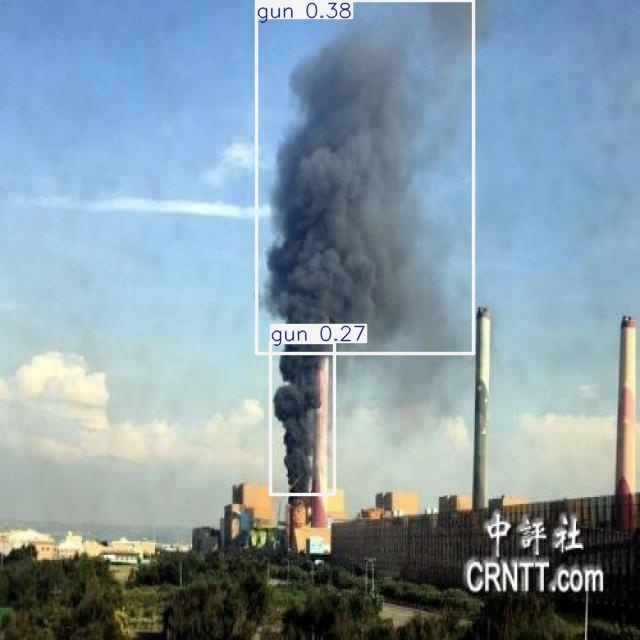

goec_car4_mp4-0330_jpg.rf.2379d7c70f9604c15a7f37fa3524c299.jpg


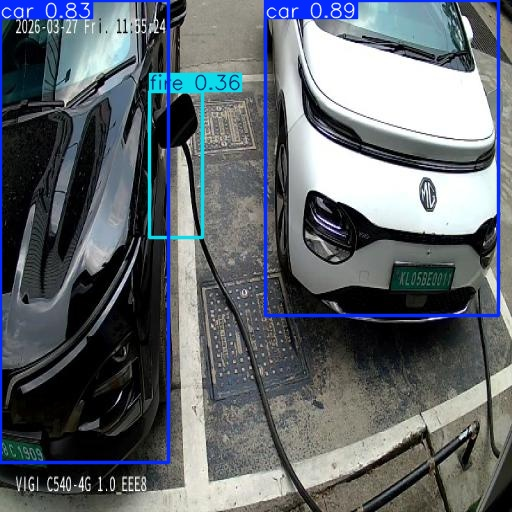

In [ ]:
import os
import random
from IPython.display import Image, display

result_dir = '/content/runs/detect/runs/test/results'
images = os.listdir(result_dir)
sample = random.sample(images, 9)

for img in sample:
    print(img)
    display(Image(filename=os.path.join(result_dir, img), width=400))

In [ ]:
# Check label files from each dataset
import os

def check_classes(dataset_path, split='train', n=5):
    label_dir = os.path.join(dataset_path, split, 'labels')
    files = os.listdir(label_dir)[:n]
    print(f"\n--- {dataset_path} ---")
    for f in files:
        with open(os.path.join(label_dir, f)) as fp:
            lines = fp.readlines()
            classes = set([line.split()[0] for line in lines])
            print(f"{f}: classes used = {classes}")

check_classes(dataset1.location)  # Cars
check_classes(dataset2.location)  # Fire & Smoke
check_classes(dataset3.location)  # GOEC


--- /content/car-detection-1 ---
0e0a995d6c459ab1_jpg.rf.be0ac4aeaa7ec9511829e6f1064bbc61.txt: classes used = {'0'}
13b2a10963b745b0_jpg.rf.34e3c3104948f36f7235c6000b422c2a.txt: classes used = {'0'}
02d59bca1a1d320b_jpg.rf.b90b0226c43747d16f0c101df3fc5079.txt: classes used = {'0'}
08602554e6937e50_jpg.rf.94482c73c0878d319b0bd76e730cbdc3.txt: classes used = {'0'}
05b3fe9aec593f3d_jpg.rf.24a0e55bb4ab703cd5173a4fb189a0e2.txt: classes used = {'0'}

--- /content/Fire-and-Smoke-7 ---
f10_frame_0618_jpg.rf.076ecf5f19e3cc0b6553a343e1d770e7.txt: classes used = {'0', '2'}
middle_-2702-_jpg.rf.4ad3deffdfa8a8e8a3ef85747b24c56c.txt: classes used = {'1'}
0190_jpg.rf.3f49f11aa9233227bc211ab86031e61b.txt: classes used = {'0'}
large_-1491-_jpg.rf.eacd9d69626aeb85c999c53fb2721865.txt: classes used = {'0', '2'}
middle_-265-_jpg.rf.e6fee830ea56a59cddb81be32e1184b5.txt: classes used = {'2'}

--- /content/GOEC-4 ---
output6-00_15_42_426-00_16_38_068-seg5_mp4-0010_jpg.rf.5086cd70f8fcc73ad166ebbbee539091.txt

In [ ]:
with open(f"{dataset2.location}/data.yaml") as f:
    print(f.read())

names:
- fire
- other
- smoke
nc: 3
roboflow:
  license: CC BY 4.0
  project: fire-and-smoke-lkzok
  url: https://universe.roboflow.com/fire-project/fire-and-smoke-lkzok/dataset/7
  version: 7
  workspace: fire-project
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
import os
import shutil
import random

random.seed(42)

# ── Remapping rules ───────────────────────────────────────────────────────────
# Cars:  0=car → 0
# Fire:  0=fire → 1, 1=other → skip, 2=smoke → 3
# GOEC:  0=car → 0, 1=gun → 2

CAR_REMAP  = {'0': '0'}
FIRE_REMAP = {'0': '1', '1': None, '2': '3'}  # None = skip
GOEC_REMAP = {'0': '0', '1': '2'}

def remap_label_file(src, dst, remap):
    with open(src) as f:
        lines = f.readlines()
    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts:
            continue
        cls = parts[0]
        new_cls = remap.get(cls)
        if new_cls is None:
            continue  # skip this class
        new_lines.append(new_cls + ' ' + ' '.join(parts[1:]) + '\n')
    if new_lines:
        with open(dst, 'w') as f:
            f.writelines(new_lines)

# ── Recreate combined folders ─────────────────────────────────────────────────
for split in ["train", "valid", "test"]:
    shutil.rmtree(f"combined/{split}", ignore_errors=True)
    os.makedirs(f"combined/{split}/images", exist_ok=True)
    os.makedirs(f"combined/{split}/labels", exist_ok=True)

# ── Split GOEC into train/valid/test ──────────────────────────────────────────
goec_images = os.listdir(f"{dataset3.location}/train/images")
random.shuffle(goec_images)
total = len(goec_images)
train_end = int(0.7 * total)
valid_end = int(0.9 * total)
goec_splits = {
    "train": goec_images[:train_end],
    "valid": goec_images[train_end:valid_end],
    "test":  goec_images[valid_end:]
}

limits = {
    "train": min(len(goec_splits["train"]), 7500, 8468),
    "valid": min(len(goec_splits["valid"]), 1500, 2314),
    "test":  min(len(goec_splits["test"]),  1000, 1149)
}

# ── Copy + remap function ─────────────────────────────────────────────────────
def copy_remap(dataset, split, filenames, limit, prefix, remap):
    filenames = random.sample(filenames, min(limit, len(filenames)))
    for fname in filenames:
        name = os.path.splitext(fname)[0]
        src_img = f"{dataset}/{split}/images/{fname}"
        src_lbl = f"{dataset}/{split}/labels/{name}.txt"
        dst_img = f"combined/{split}/images/{prefix}_{fname}"
        dst_lbl = f"combined/{split}/labels/{prefix}_{name}.txt"
        if os.path.exists(src_img):
            shutil.copy(src_img, dst_img)
        if os.path.exists(src_lbl):
            remap_label_file(src_lbl, dst_lbl, remap)

# ── Cars ──────────────────────────────────────────────────────────────────────
for split in ["train", "valid", "test"]:
    imgs = os.listdir(f"{dataset1.location}/{split}/images")
    copy_remap(dataset1.location, split, imgs, limits[split], "car", CAR_REMAP)

# ── Fire & Smoke ──────────────────────────────────────────────────────────────
for split in ["train", "valid", "test"]:
    imgs = os.listdir(f"{dataset2.location}/{split}/images")
    copy_remap(dataset2.location, split, imgs, limits[split], "fire", FIRE_REMAP)

# ── GOEC ──────────────────────────────────────────────────────────────────────
for split in ["train", "valid", "test"]:
    imgs = goec_splits[split]
    for fname in random.sample(imgs, min(limits[split], len(imgs))):
        name = os.path.splitext(fname)[0]
        src_img = f"{dataset3.location}/train/images/{fname}"
        src_lbl = f"{dataset3.location}/train/labels/{name}.txt"
        dst_img = f"combined/{split}/images/goec_{fname}"
        dst_lbl = f"combined/{split}/labels/goec_{name}.txt"
        if os.path.exists(src_img):
            shutil.copy(src_img, dst_img)
        if os.path.exists(src_lbl):
            remap_label_file(src_lbl, dst_lbl, GOEC_REMAP)

print("Done! Remapped dataset created.")
for split in ["train", "valid", "test"]:
    count = len(os.listdir(f"combined/{split}/images"))
    print(f"{split}: {count} images")

Done! Remapped dataset created.
train: 6237 images
valid: 1782 images
test: 891 images


In [ ]:
yaml_content = """names:
- car
- fire
- gun
- smoke
nc: 4
train: /content/combined/train/images
val: /content/combined/valid/images
test: /content/combined/test/images
"""

with open("combined/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated!")

data.yaml updated!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="combined/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device="cuda",
    project="runs/train",
    name="combined_v2",
    save=True,
)

print("Training complete!")
print("Best weights: runs/train/combined_v2/weights/best.pt")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=combined/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=combined_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

In [ ]:
from google.colab import files
files.download('/content/runs/detect/runs/train/combined_v2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/runs/train/combined_v2/weights/best.pt')

results = model.predict(
    source='/content/combined/test/images',
    conf=0.25,
    save=True,
    project='runs/test',
    name='results_v2'
)

print("Done!")


image 1/891 /content/combined/test/images/car_000297578acb067b_jpg.rf.4748165575afa020176198742f43f305.jpg: 640x640 2 cars, 7.2ms
image 2/891 /content/combined/test/images/car_000472189adb5cbd_jpg.rf.1159b5f6af54206fc6628fd5a4c94f4c.jpg: 640x640 3 cars, 7.2ms
image 3/891 /content/combined/test/images/car_00058138dc1ecd17_jpg.rf.dfeb1ef3fc9206d4b11e27dd953cd7ac.jpg: 640x640 1 car, 7.8ms
image 4/891 /content/combined/test/images/car_000e7c5f11d82f1a_jpg.rf.309e92efda969f82dea0d624daee93b3.jpg: 640x640 (no detections), 7.2ms
image 5/891 /content/combined/test/images/car_00118c8deaacd309_jpg.rf.16483ee1ceb4909dc66463758f0fa338.jpg: 640x640 1 car, 7.2ms
image 6/891 /content/combined/test/images/car_001296b93b636dfb_jpg.rf.2fa8eb565618ed2723d3904c7c4134d6.jpg: 640x640 1 car, 7.2ms
image 7/891 /content/combined/test/images/car_001493fd26374606_jpg.rf.e1b638cfc61da4ee8a03a8bfa6da5f4a.jpg: 640x640 2 cars, 7.2ms
image 8/891 /content/combined/test/images/car_00155bc9538a26ed_jpg.rf.e9b3476e5f50d

car_0809580a25a3aa67_jpg.rf.53e658c61499d48f3c0c27a41b8dac10.jpg


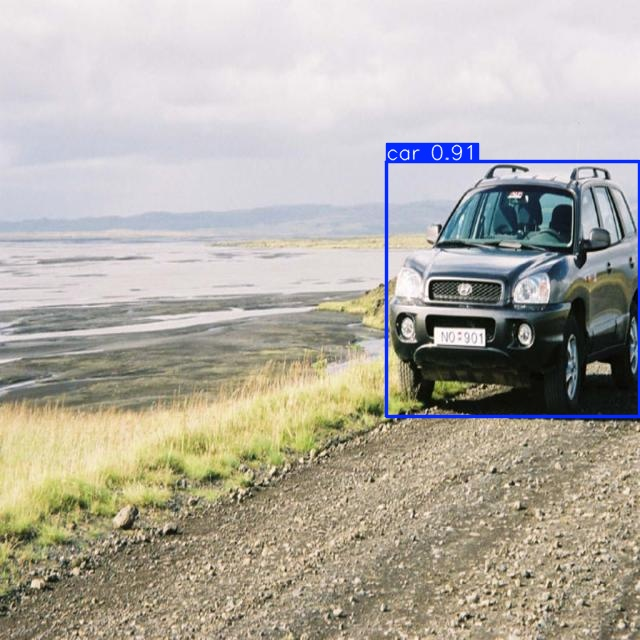

car_06f5ea5297cf90fe_jpg.rf.c68b9413869340a03273b274899facca.jpg


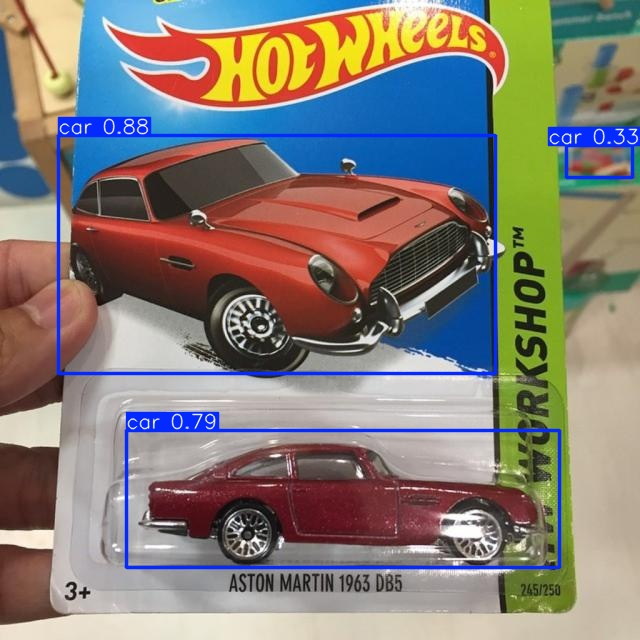

car_16249801ed5c333e_jpg.rf.af43617464c87ea1a5cbecad0baa4f67.jpg


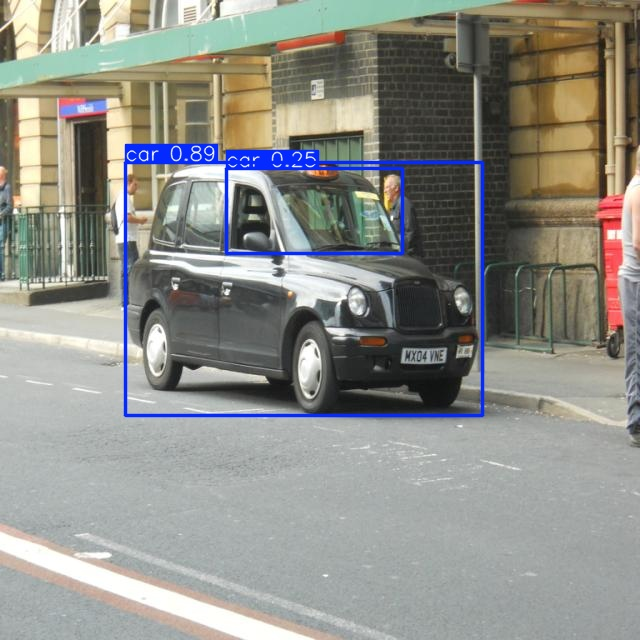

fire_s3_frame_0160_jpg.rf.9a65af07277140266cec36e7fe035429.jpg


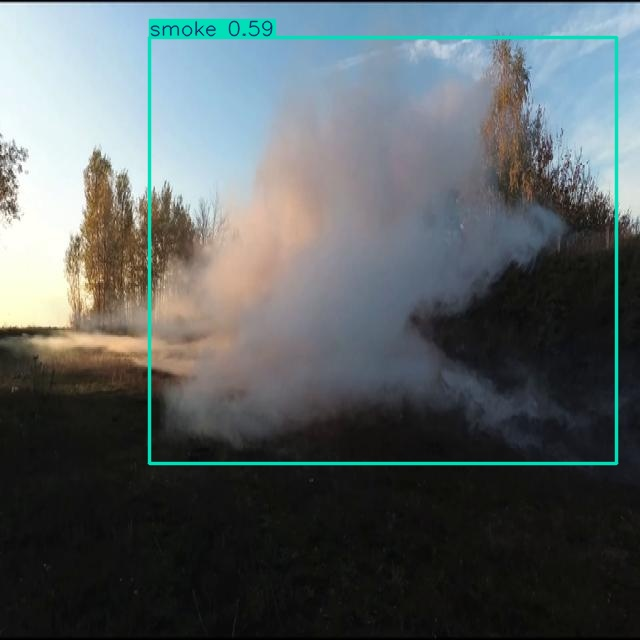

fire_large_-2278-_jpg.rf.1594779b3c24150c64c30a7673f54876.jpg


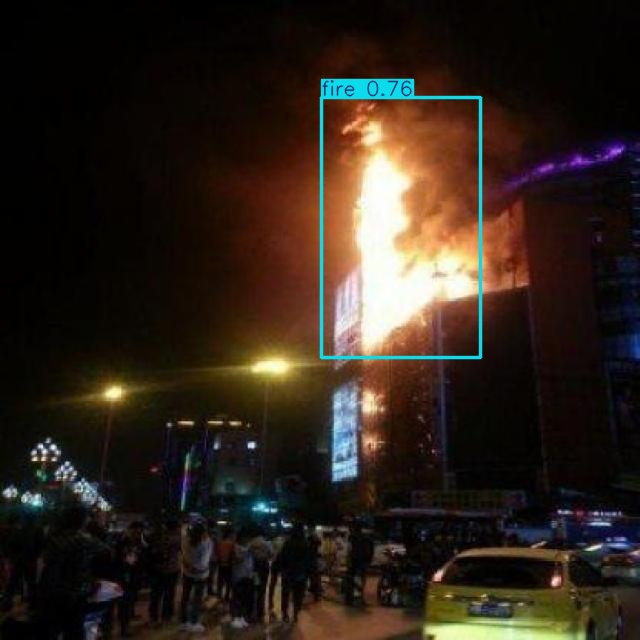

fire_f10_frame_0263_jpg.rf.bec514d625e4bd3ec3669bb417891a02.jpg


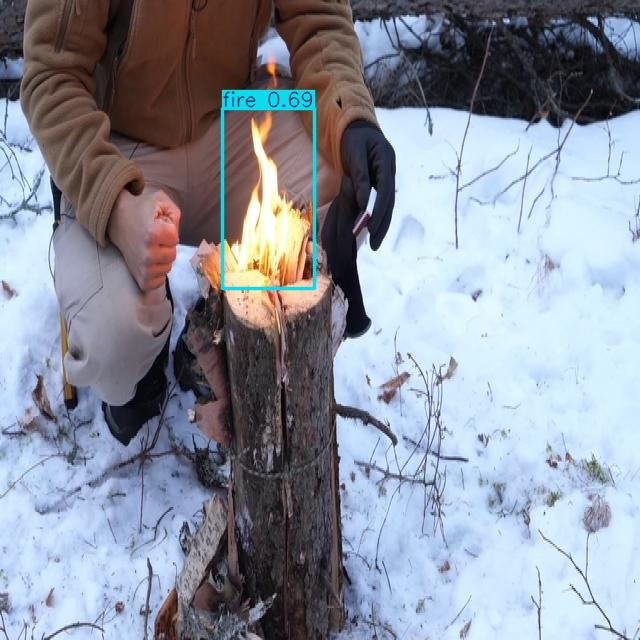

goec_car1_mp4-0076_jpg.rf.e33759a9bf496ee573951c314455d198.jpg


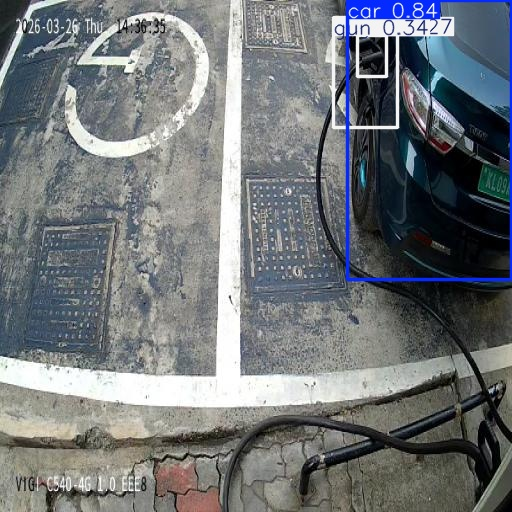

goec_capture_2026-03-30_23-20-00_mp4-0596_jpg.rf.aadaf1566c7627a73901a81f5d5e3e72.jpg


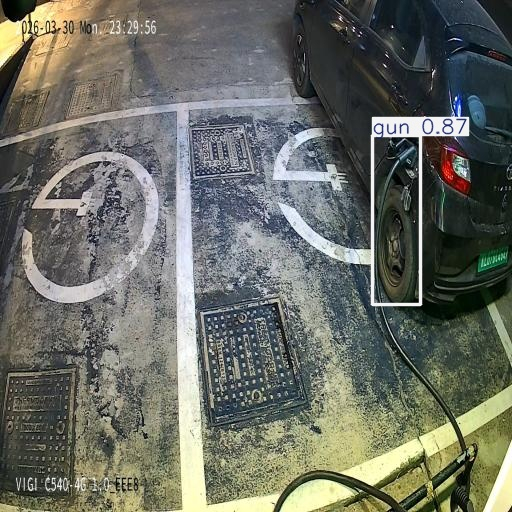

goec_car2_mp4-0074_jpg.rf.5ed7667c0bd3e3edf56b1d894ace175d.jpg


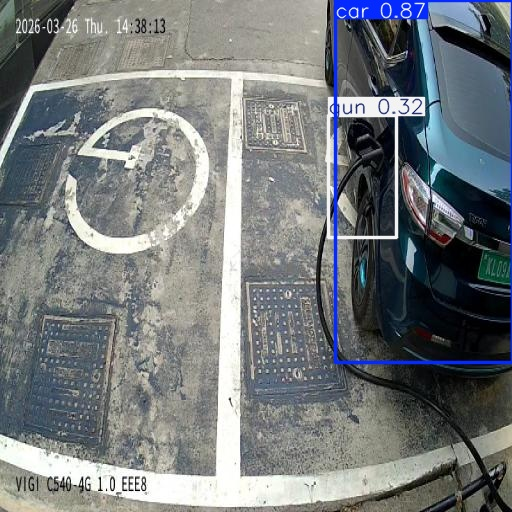

In [ ]:
import os
import random
from IPython.display import Image, display

result_dir = '/content/runs/detect/runs/test/results_v2'
images = os.listdir(result_dir)

# Show some from each category
car_imgs = [f for f in images if f.startswith('car_')][:3]
fire_imgs = [f for f in images if f.startswith('fire_')][:3]
goec_imgs = [f for f in images if f.startswith('goec_')][:3]

for img in car_imgs + fire_imgs + goec_imgs:
    print(img)
    display(Image(filename=os.path.join(result_dir, img), width=400))

fire_middle_-798-_jpg.rf.471fc425a2928921d83b908c6ac3a6a8.jpg


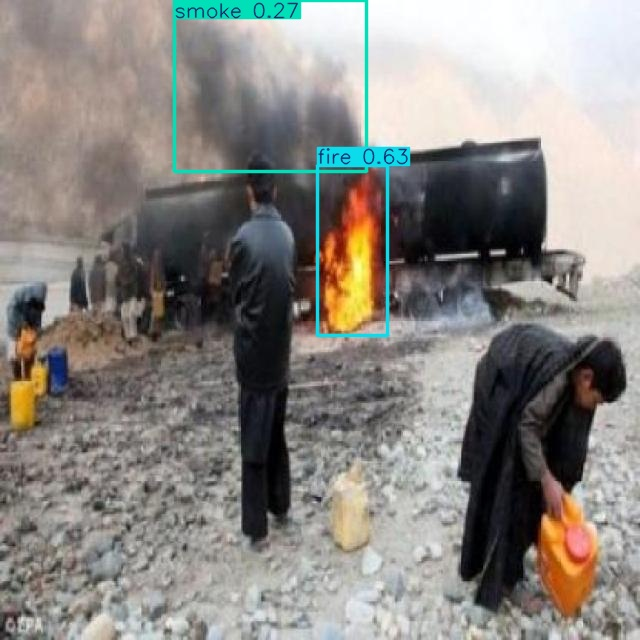

goec_car2_mp4-0079_jpg.rf.542262af86abc29d1f03075d0641ab01.jpg


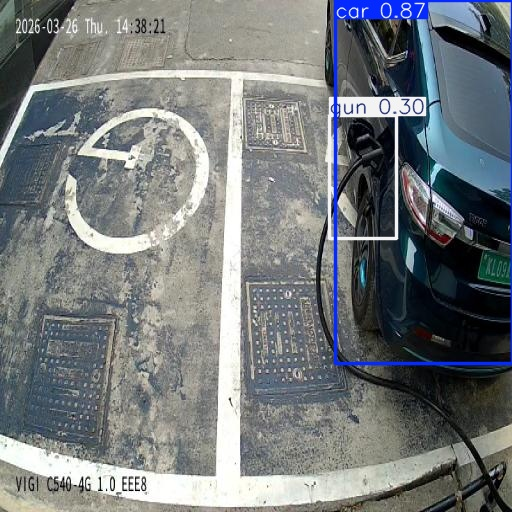

car_0cdb464a57be70b6_jpg.rf.8f2a539a051a4eeddc885182b027e3b3.jpg


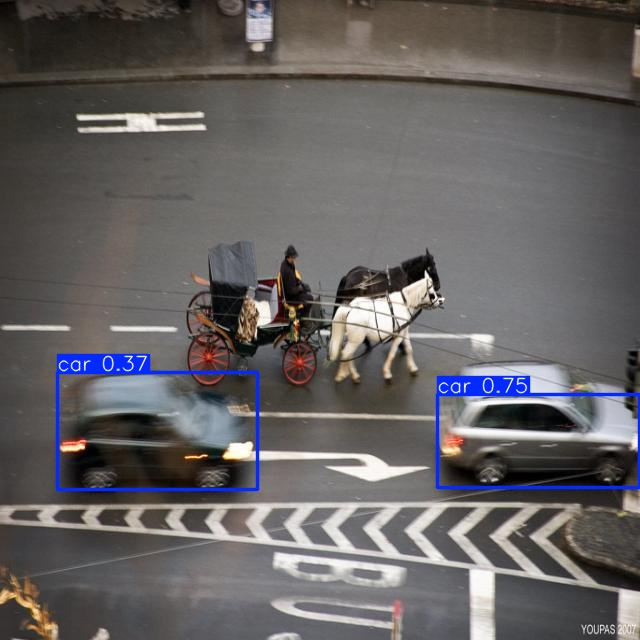

goec_output6-00_19_24_992-00_20_07_882-seg8_mp4-0001_jpg.rf.cf7d0a47781ca0842a1d44ac3c577bf0.jpg


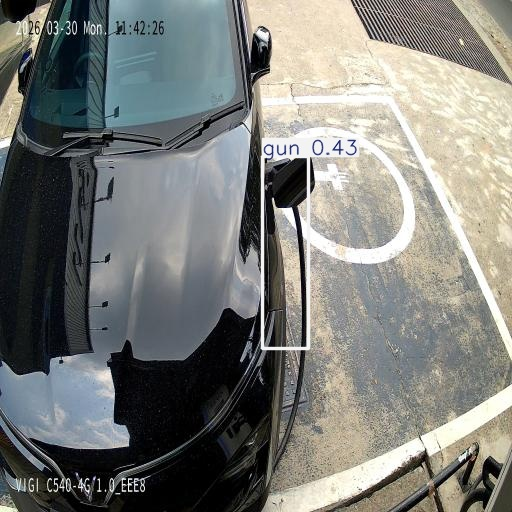

fire_other_-978-_jpg.rf.255e40f4e69851ded3308b0a8679d3f2.jpg


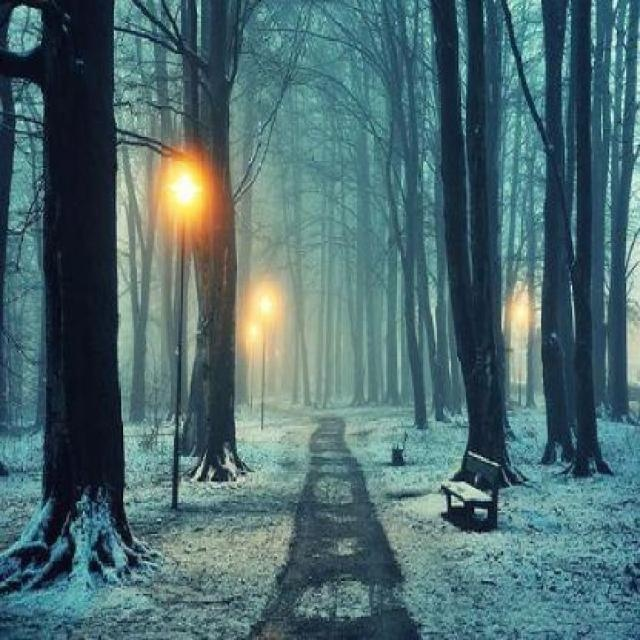

car_15af592f8372321d_jpg.rf.1b74dbad66c6438b7c390a07cd35f3cc.jpg


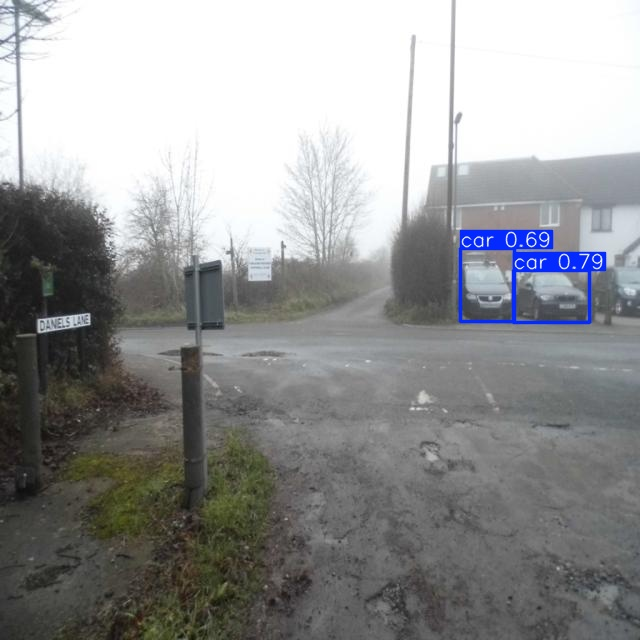

car_01b8f082ffa7e14d_jpg.rf.ea60182e2b904289a70e780164146b6e.jpg


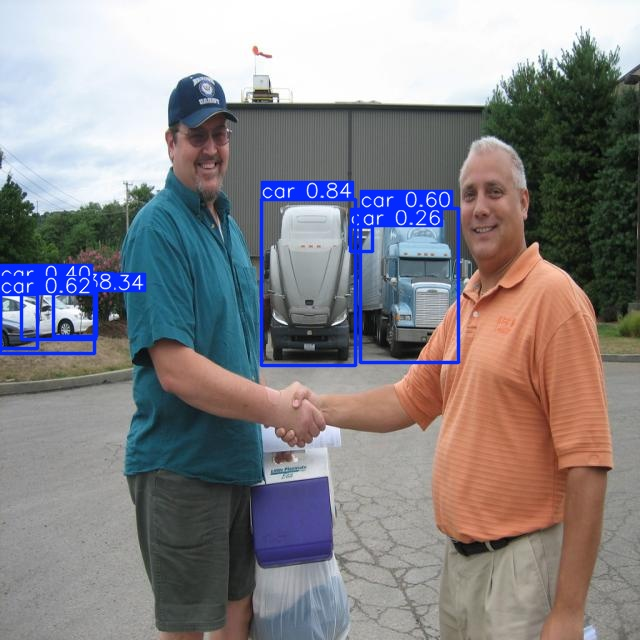

fire_200449_jpg.rf.7b25d3bc98eb2b783810dbd0a83ecf18.jpg


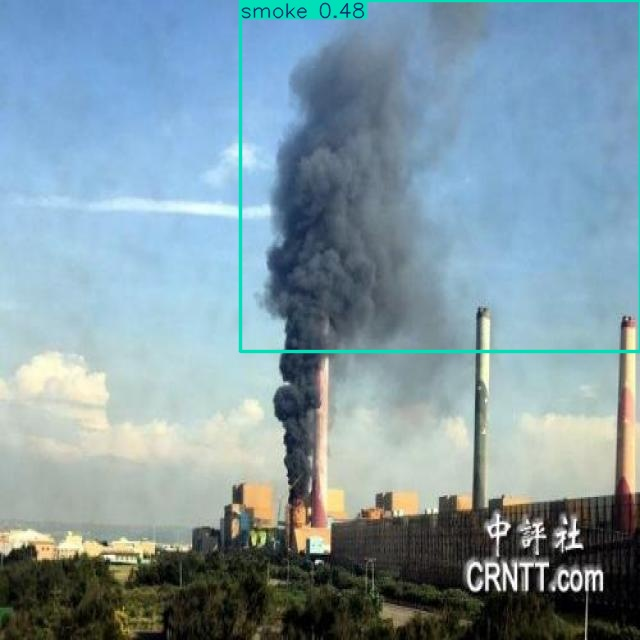

goec_car4_mp4-0330_jpg.rf.2379d7c70f9604c15a7f37fa3524c299.jpg


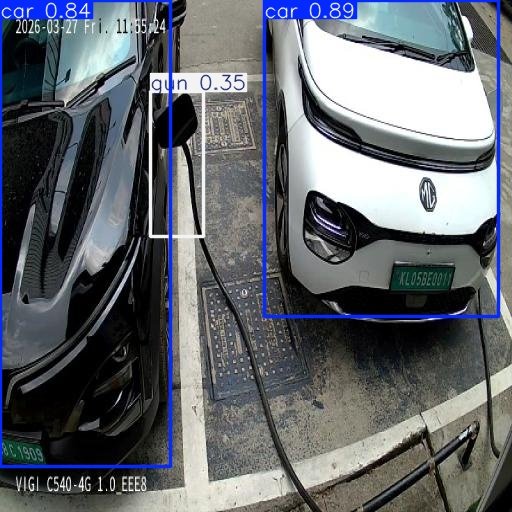

car_13c5214e520c2ad7_jpg.rf.451b9ff8f7f34e800a690c6815e6c993.jpg


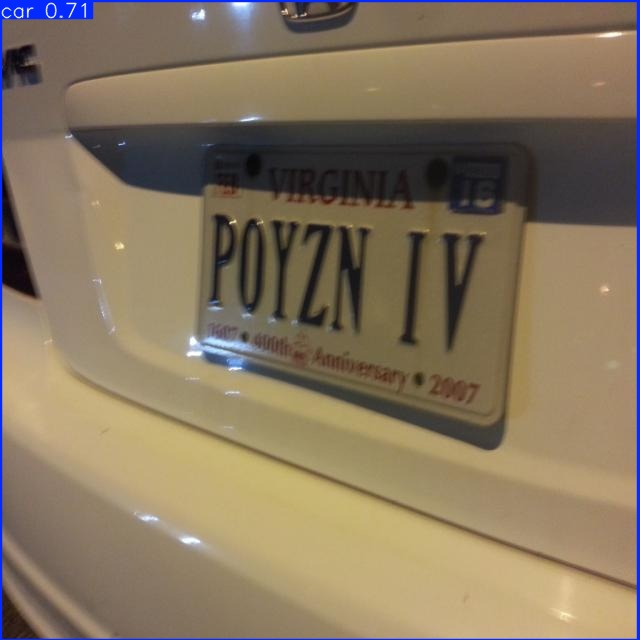

fire_10354256-hd_1080_1920_30fps_mp4-0025_jpg.rf.8eaf4185154f48bcfc7921997ee4b2a7.jpg


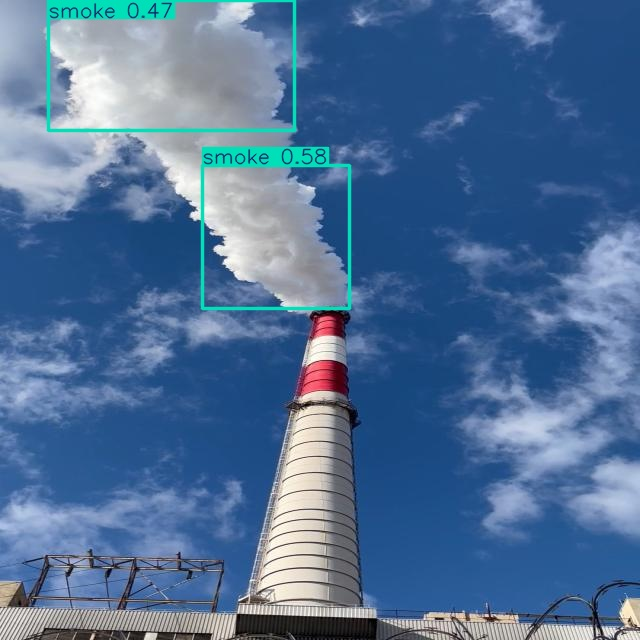

car_02ee0c16ce381b1c_jpg.rf.621820df4262e4cbc190f45dbe3ffccc.jpg


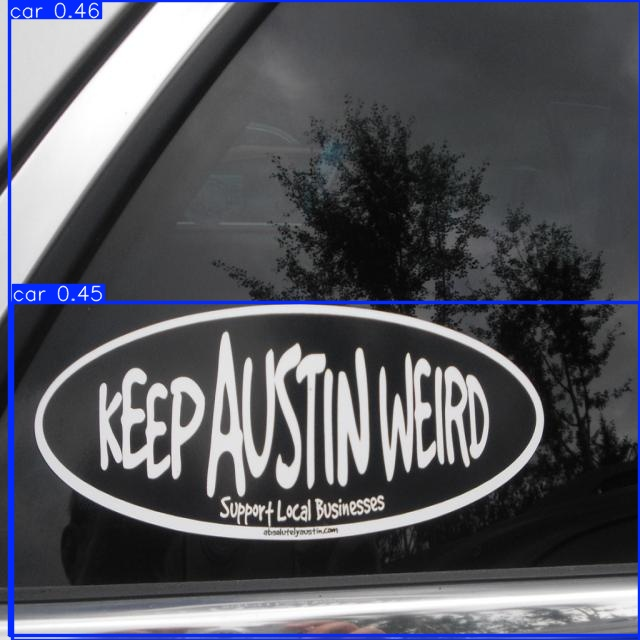

fire_1058963414-preview_mp4-0193_jpg.rf.b4dd2797c5ddbe68c931dd33a4282f2a.jpg


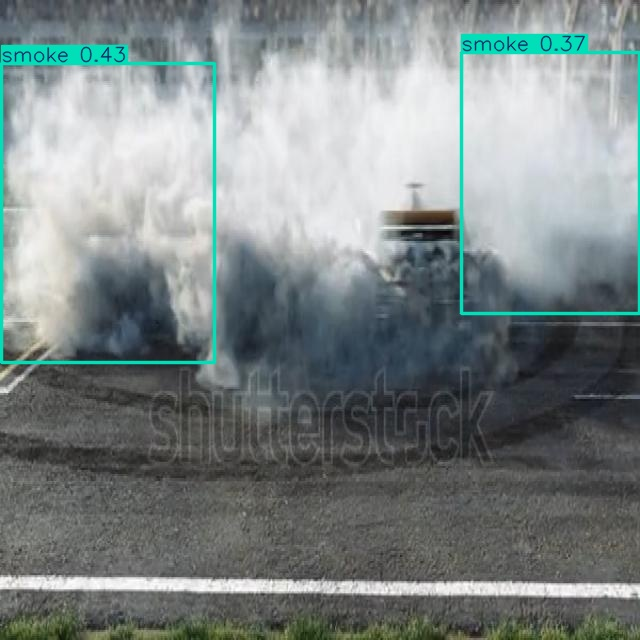

fire_3813298909-preview_mp4-0009_jpg.rf.d37d8344e57005941009ff574caa226c.jpg


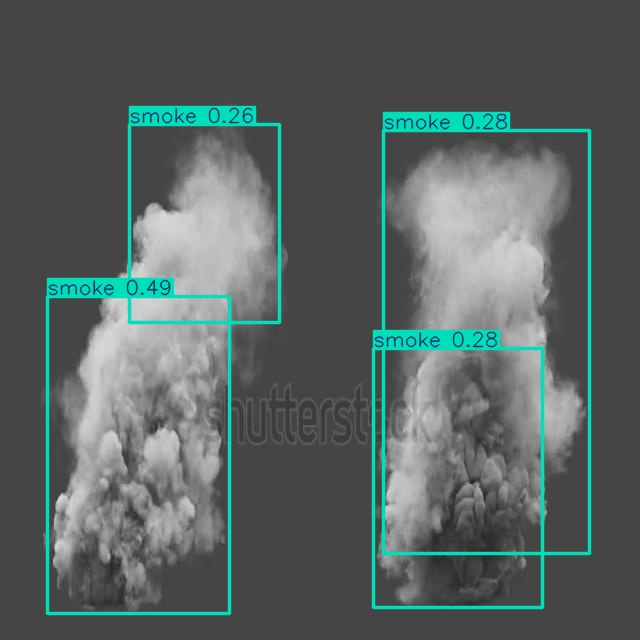

goec_output6-00_15_42_426-00_16_38_068-seg5_mp4-0041_jpg.rf.42b3e5d99f530037e5994a68e6048151.jpg


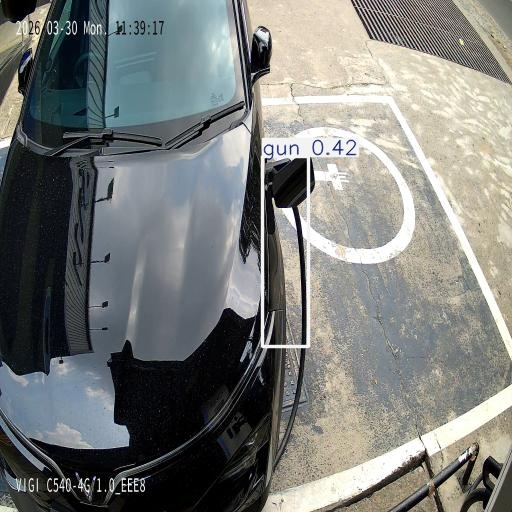

fire_Centerville-area-closed-off-due-to-transformer-fire_mp4-0125_jpg.rf.415944ccc8dcba8f0fd40bc7bd42bee8.jpg


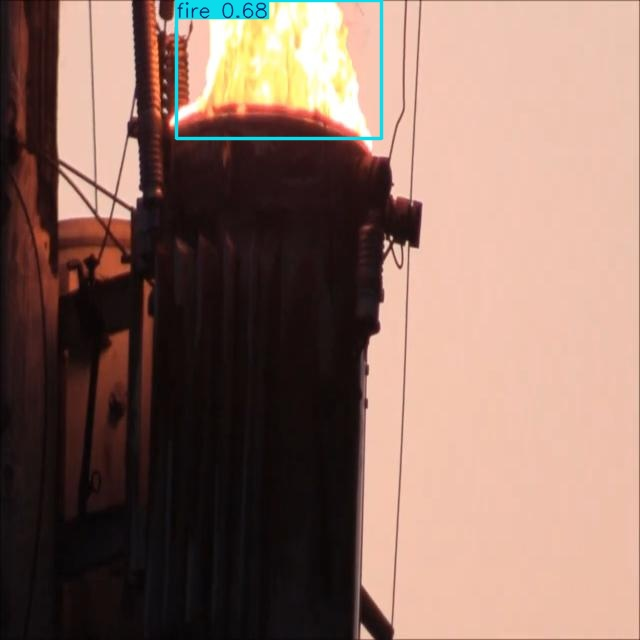

fire_middle_-1927-_jpg.rf.baa80045ea42ea4c48857f91b5d806ee.jpg


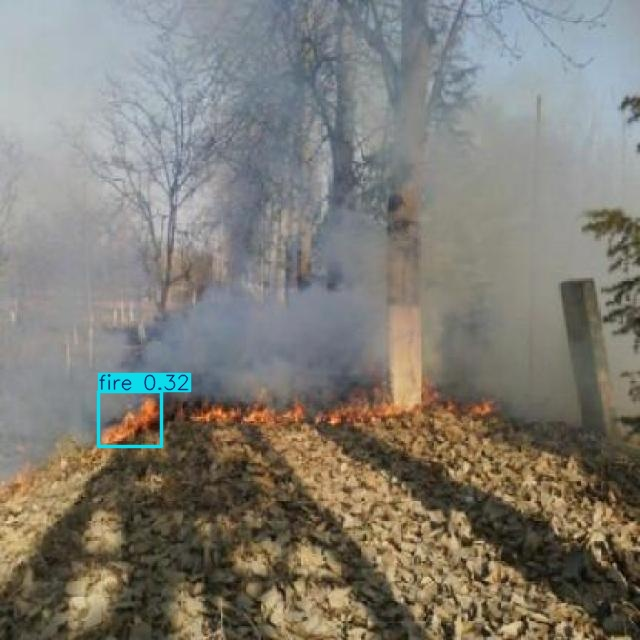

fire_10354256-hd_1080_1920_30fps_mp4-0075_jpg.rf.79b5b718bd7382023b2afddb47855e1c.jpg


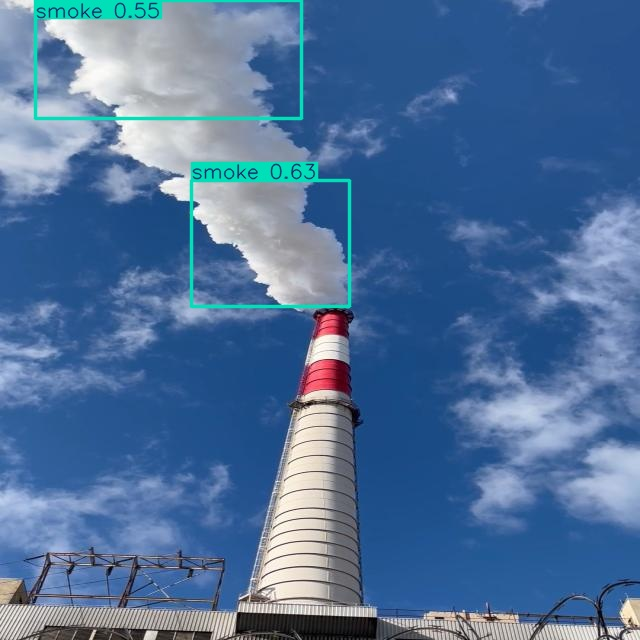

car_06b8beb6a1f56394_jpg.rf.146d303e58e483098e22f3d5ca163566.jpg


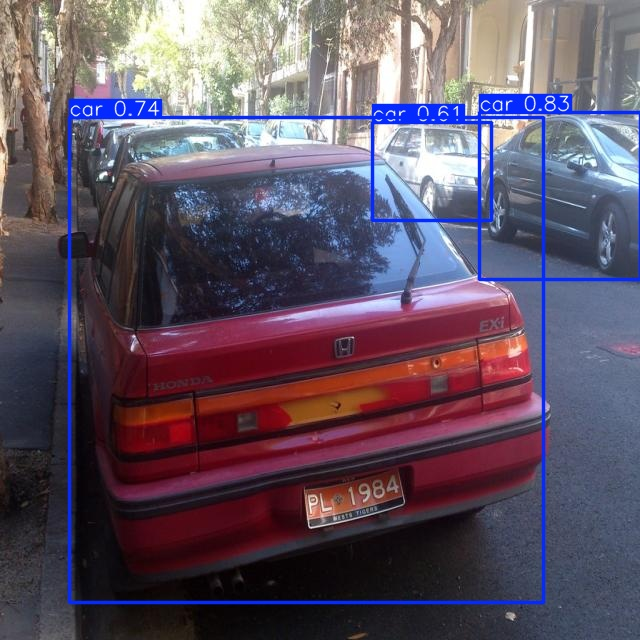

goec_capture_2026-03-30_23-20-00_mp4-0075_jpg.rf.a32cb26cd608841c8ffc2bdd92732896.jpg


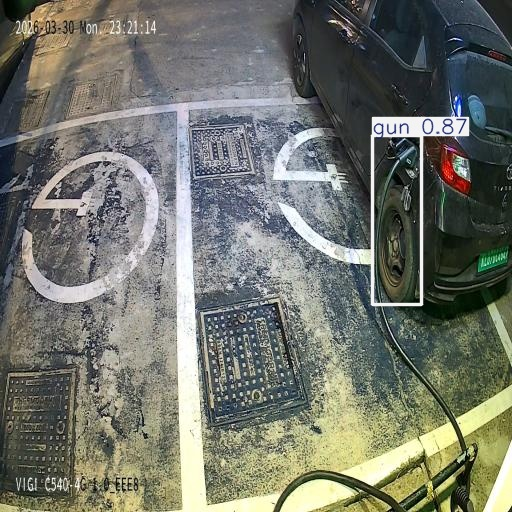

In [ ]:
import os
import random
from IPython.display import Image, display

result_dir = '/content/runs/detect/runs/test/results_v2'
images = os.listdir(result_dir)
sample = random.sample(images, 20)

for img in sample:
    print(img)
    display(Image(filename=os.path.join(result_dir, img), width=400))


0: 640x640 (no detections), 5.3ms
1: 640x640 2 cars, 5.3ms
2: 640x640 1 smoke, 5.3ms
3: 640x640 1 gun, 5.3ms
4: 640x640 1 car, 5.3ms
5: 640x640 2 cars, 5.3ms
6: 640x640 1 fire, 5.3ms
7: 640x640 1 gun, 5.3ms
8: 640x640 1 fire, 5.3ms
9: 640x640 1 gun, 5.3ms
10: 640x640 2 guns, 5.3ms
11: 640x640 (no detections), 5.3ms
12: 640x640 2 guns, 5.3ms
13: 640x640 1 fire, 5.3ms
14: 640x640 2 cars, 5.3ms
15: 640x640 1 fire, 5.3ms
16: 640x640 1 car, 1 gun, 5.3ms
17: 640x640 2 guns, 5.3ms
18: 640x640 2 fires, 5.3ms
19: 640x640 1 gun, 5.3ms
Speed: 2.9ms preprocess, 5.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/runs/test/results_v3


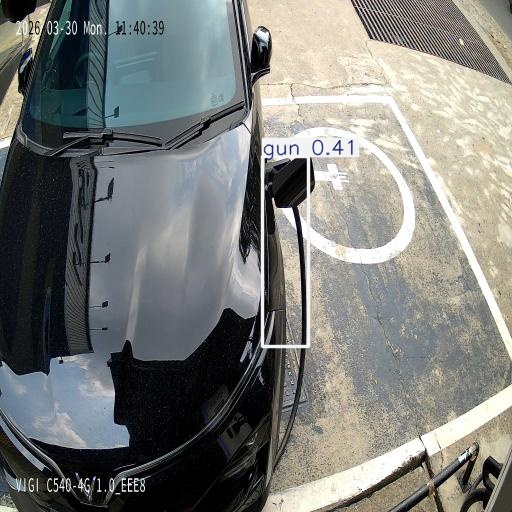

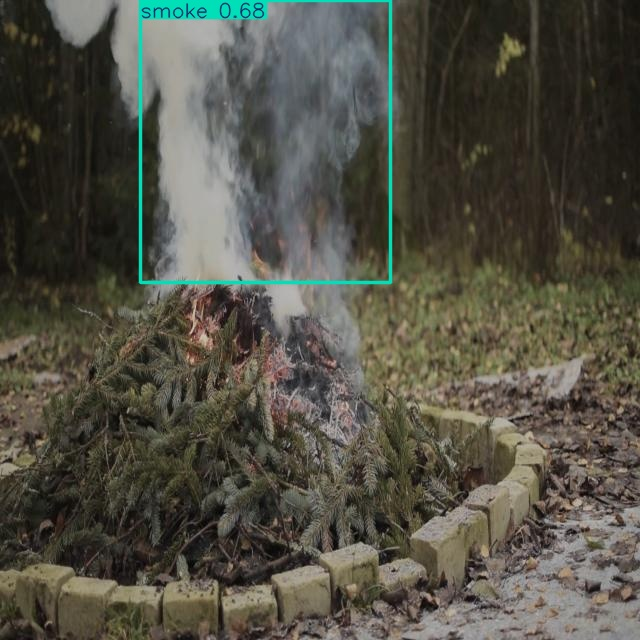

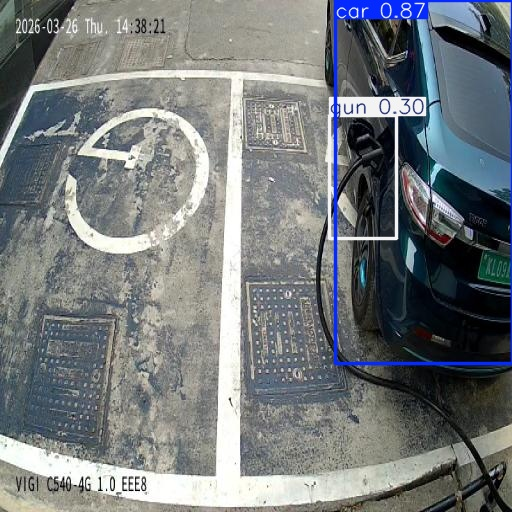

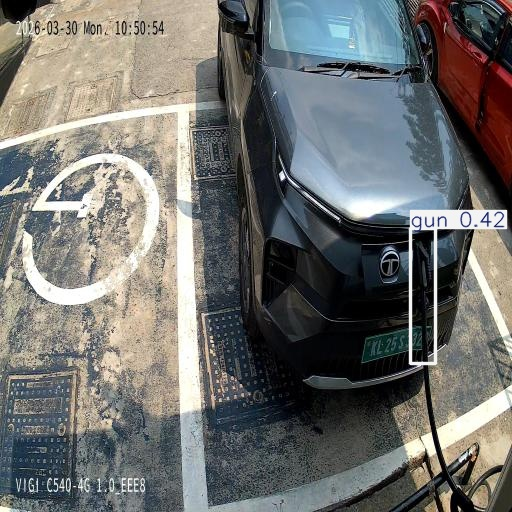

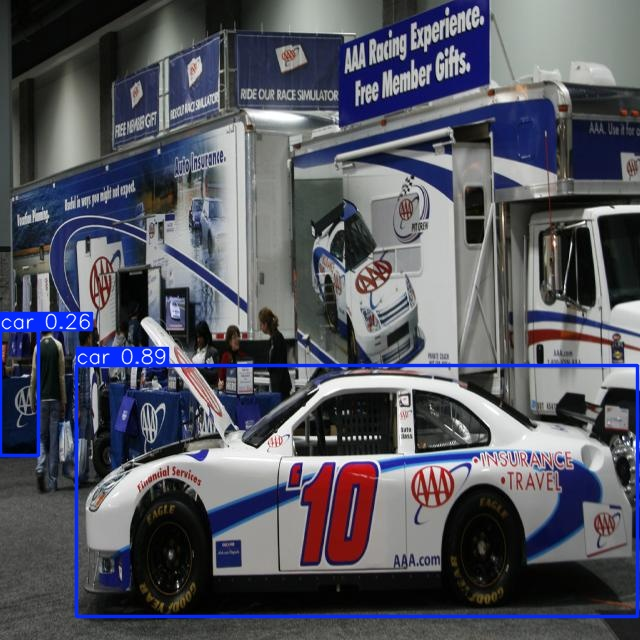

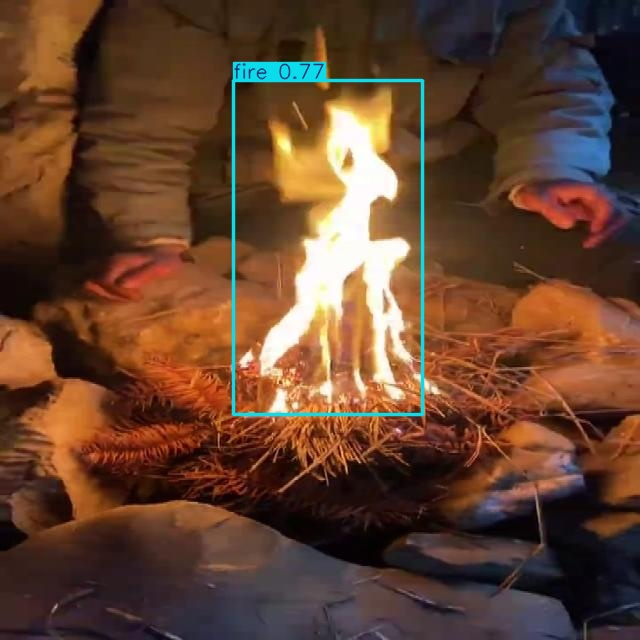

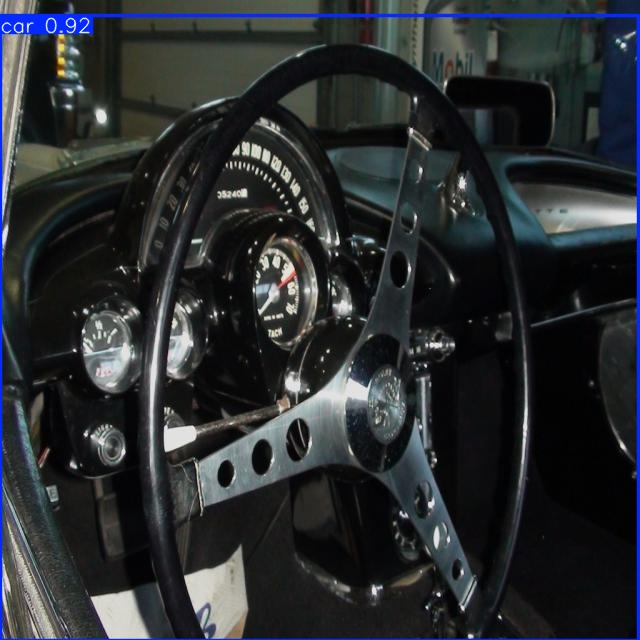

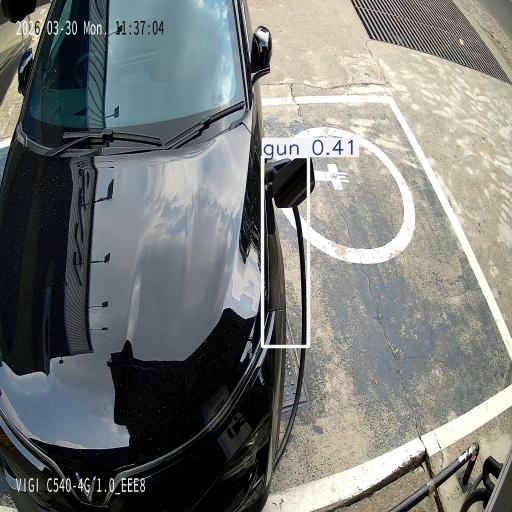

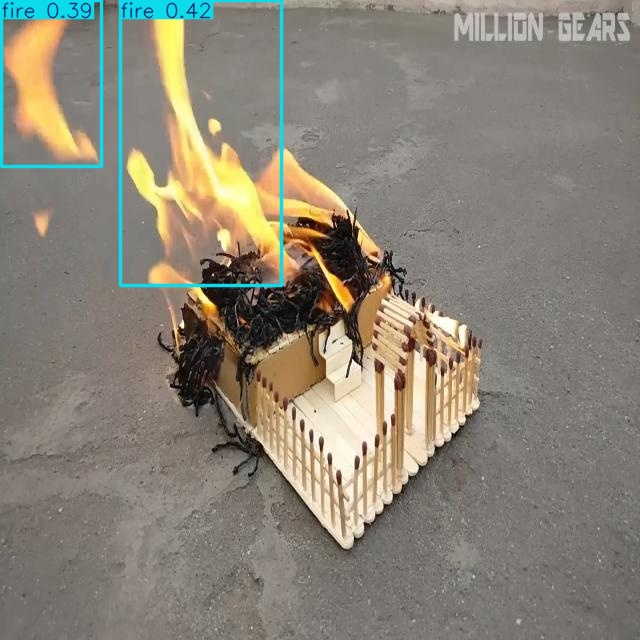

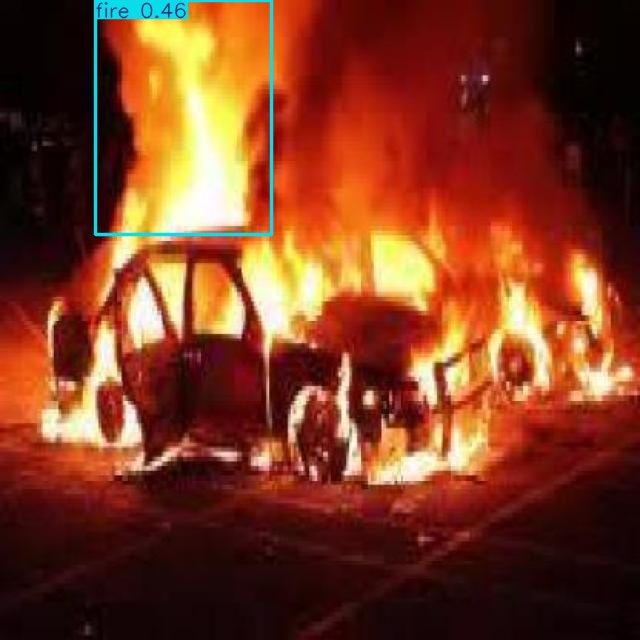

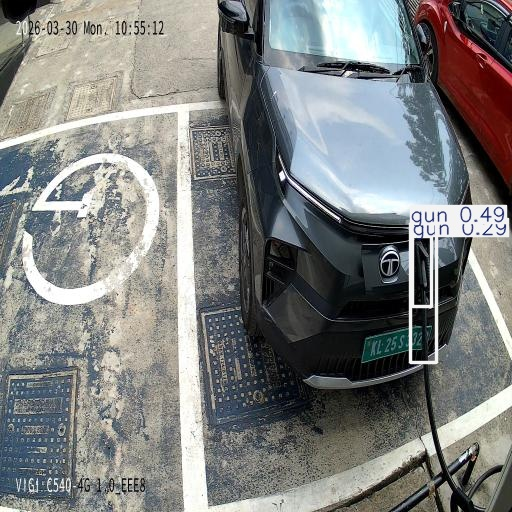

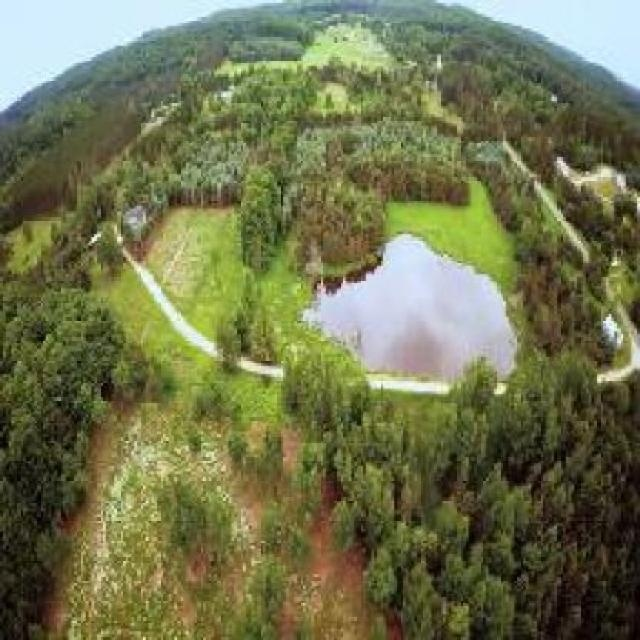

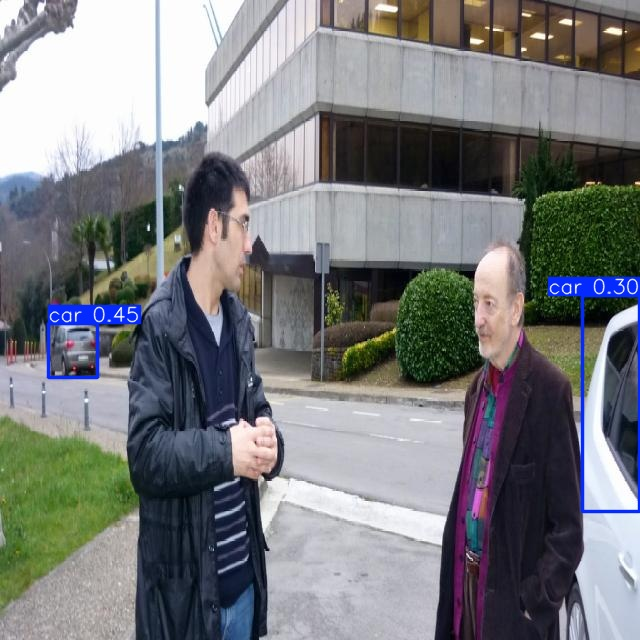

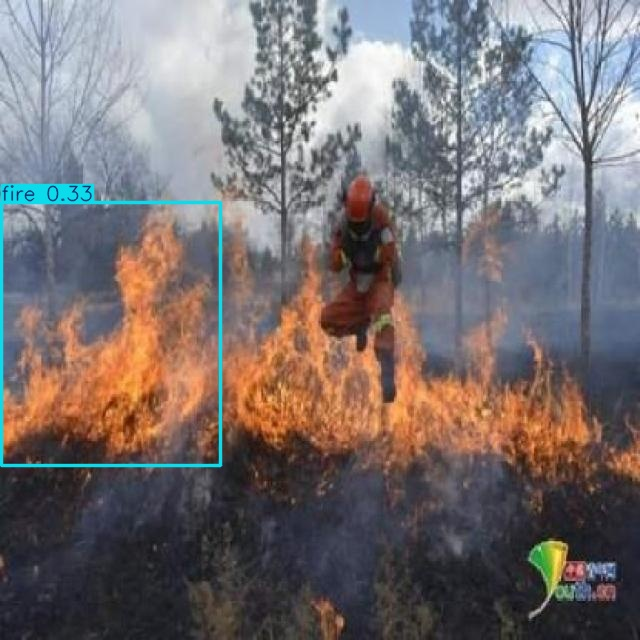

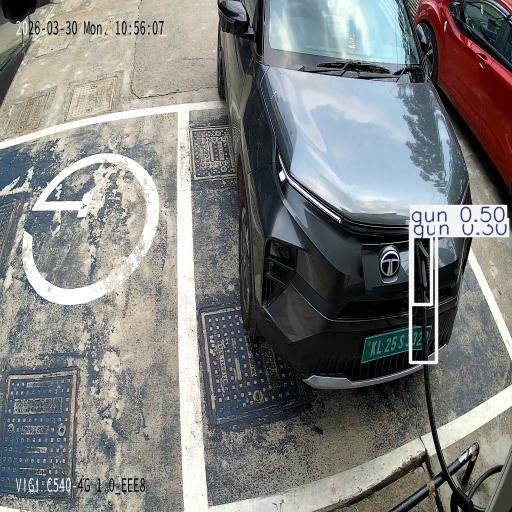

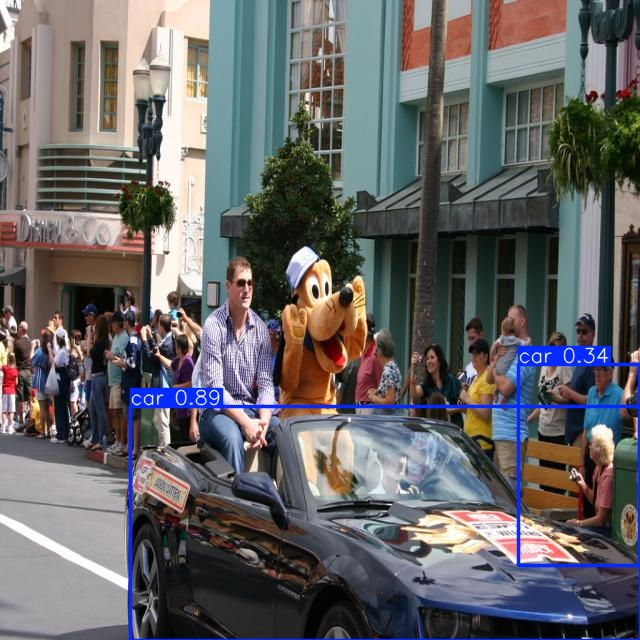

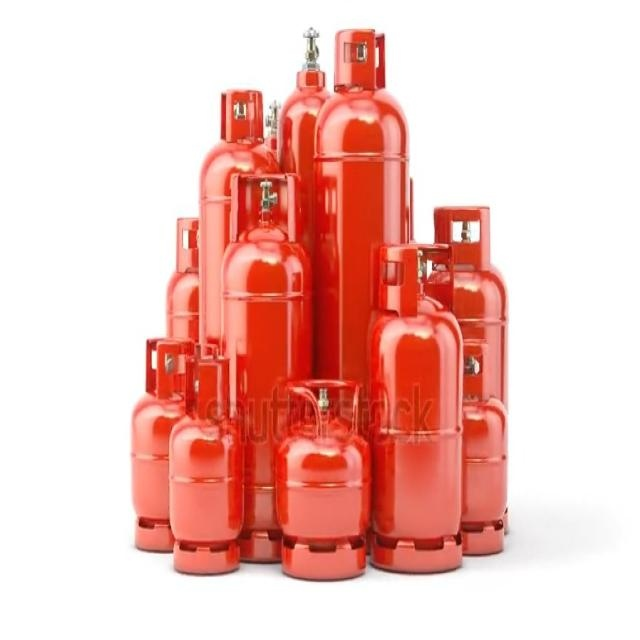

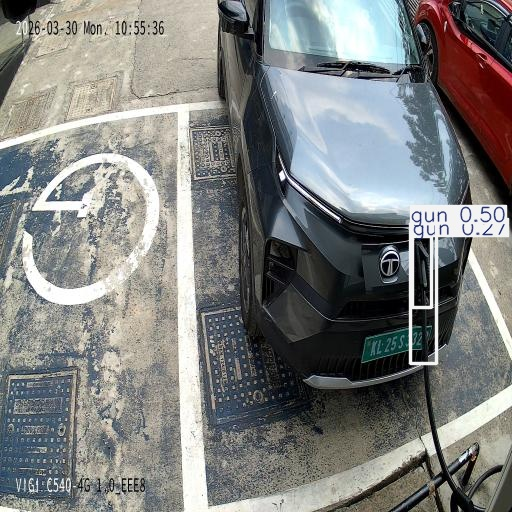

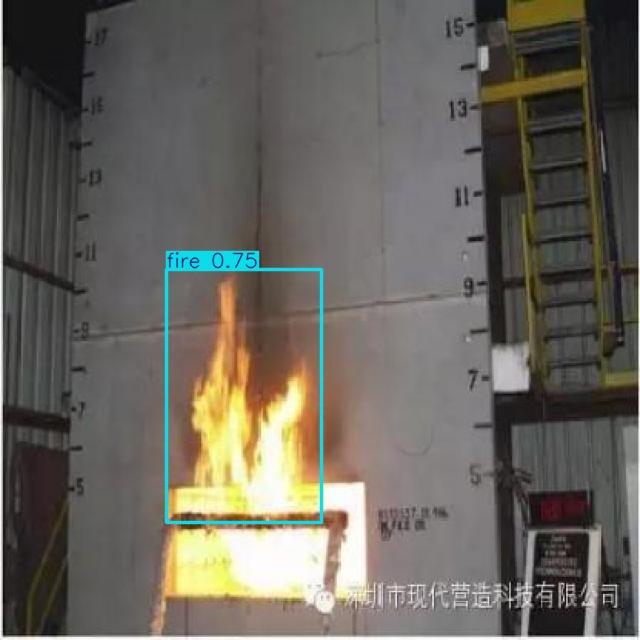

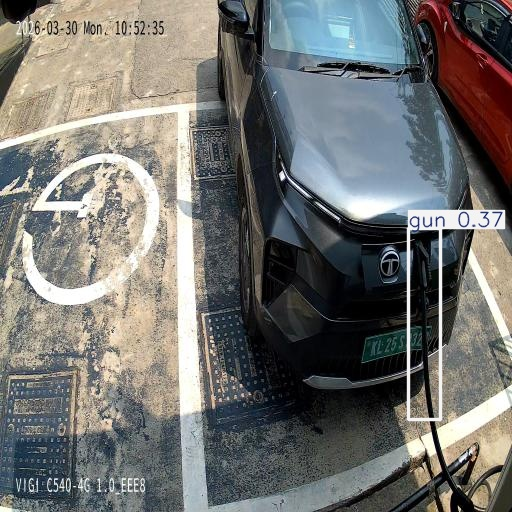

In [ ]:
from ultralytics import YOLO
import os
import random
from IPython.display import Image, display

model = YOLO('/content/runs/detect/runs/train/combined_v2/weights/best.pt')

result_dir = '/content/combined/test/images'
sample = random.sample(os.listdir(result_dir), 20)

results = model.predict(
    source=[os.path.join(result_dir, f) for f in sample],
    conf=0.25,
    iou=0.4,
    save=True,
    project='runs/test',
    name='results_v3'
)

for img in os.listdir('/content/runs/detect/runs/test/results_v3'):
    display(Image(filename=f'/content/runs/detect/runs/test/results_v3/{img}', width=400))